In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import scipy.io
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import xarray as xr
#from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset, random_split

In [3]:
def coriolis_force(lat):
    omega = 2 * np.pi / (24 * 60 * 3600)
    f = 2 * omega * np.sin(lat)
    return f

In [4]:
g = 9.8
nu = 10**(-3)

In [5]:
uo_infile = 'http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/ORAS4/uo'
vo_infile = 'http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/ORAS4/vo'
zos_infile = 'http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/ORAS4/zos'

data_uo = xr.open_dataset(uo_infile)
data_vo = xr.open_dataset(vo_infile)
data_ssh = xr.open_dataset(zos_infile)

surface_uo = data_uo.sel(lev=data_uo.lev[0]) # Choosing the highest depth cuz dropping lev drops the variable
surface_vo = data_vo.sel(lev=data_vo.lev[0])

years = data_uo.time.values # In a datatime format, better to use this for plotting, and integers for training

data_uo = surface_uo.drop('lev') # Not needed, correspond to z-axis
data_vo = surface_vo.drop('lev')

u_sel = data_uo.sel(lat=slice(30, 60), lon=slice(150, 250))
v_sel = data_vo.sel(lat=slice(30, 60), lon=slice(150, 250))
ssh_sel = data_ssh.sel(lat=slice(30, 60), lon=slice(150, 250))

u_sel['time'] = np.arange(years.shape[0])
v_sel['time'] = np.arange(years.shape[0])
ssh_sel['time'] = np.arange(years.shape[0])

lat = u_sel.lat.values # Corresponds to y
lon = u_sel.lon.values # Corresponds to x

u = u_sel['uo'].values # (T, N, M)
v = v_sel['vo'].values # (T, N, M)
ssh = ssh_sel['ssh'].values # (T, N, M)

C:\Users\angel\anaconda3\Lib\site-packages\xarray\coding\times.py:154: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)


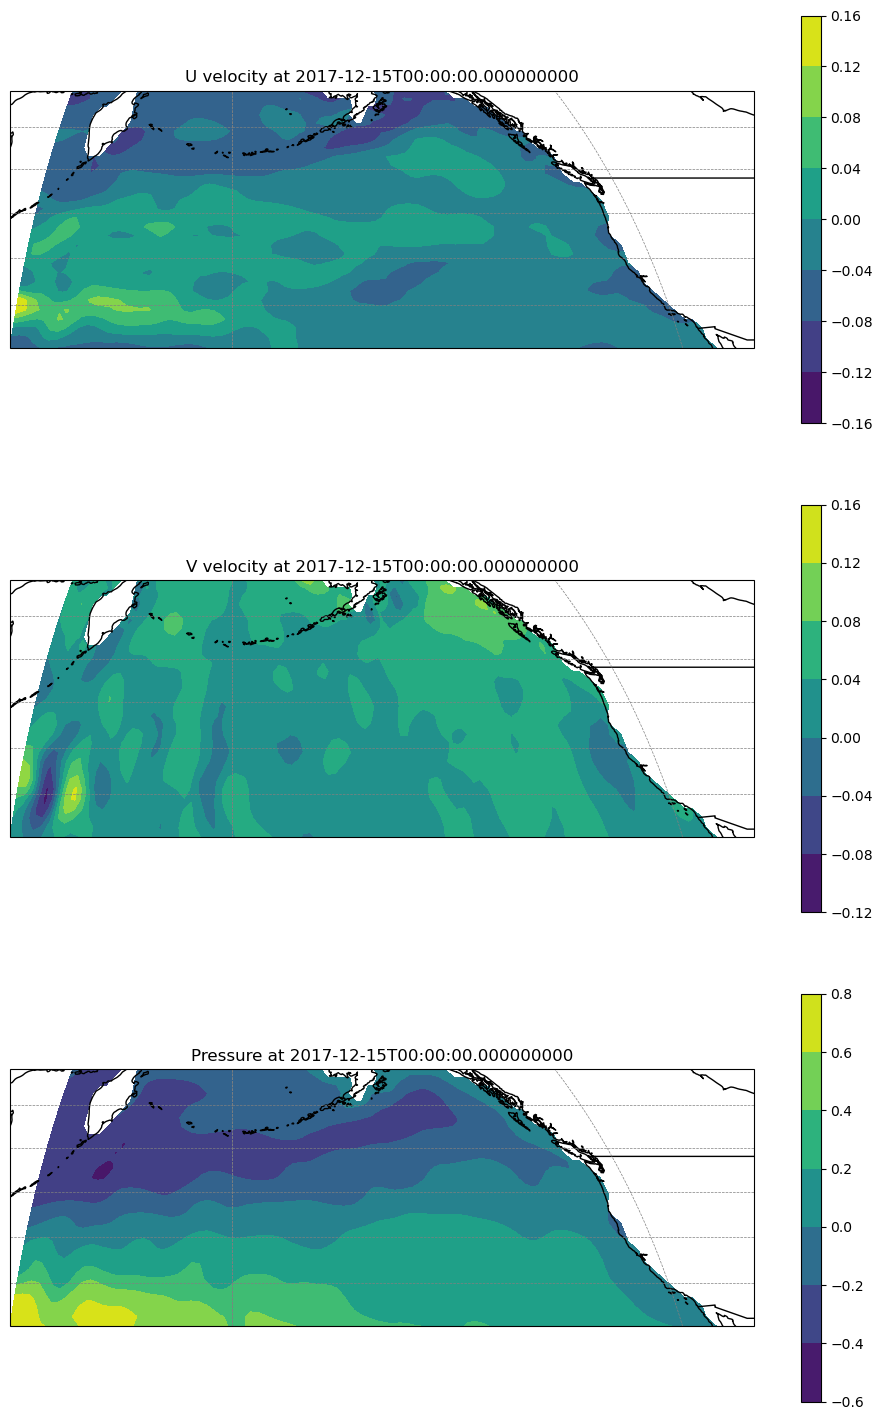

In [6]:
projection = ccrs.Mollweide(central_longitude=180)

fig, ax = plt.subplots(3, 1, figsize=(12, 18), subplot_kw={'projection': projection})

U_plot = u_sel['uo'][0,:,:].values
V_plot = v_sel['vo'][0,:,:].values
SSH_plot = ssh_sel['ssh'][0,:,:].values

pcf0 = ax[0].contourf(lon, lat, U_plot, transform=ccrs.PlateCarree(), cmap='viridis') # Same as plotting xarray
pcf1 = ax[1].contourf(lon, lat, V_plot, transform=ccrs.PlateCarree(), cmap='viridis')
pcf2 = ax[2].contourf(lon, lat, SSH_plot, transform=ccrs.PlateCarree(), cmap='viridis')

cbar0 = fig.colorbar(pcf0, ax=ax[0])
cbar1 = fig.colorbar(pcf1, ax=ax[1])
cbar2 = fig.colorbar(pcf2, ax=ax[2])

def update(frame): 
    ax[0].clear()
    ax[1].clear()
    ax[2].clear()

    U_plot = u_sel['uo'][frame,:,:].values
    V_plot = v_sel['vo'][frame,:,:].values
    SSH_plot = ssh_sel['ssh'][frame,:,:].values

    ax[0].contourf(lon, lat, U_plot, transform=ccrs.PlateCarree(), cmap='viridis') # Same as plotting xarray
    ax[1].contourf(lon, lat, V_plot, transform=ccrs.PlateCarree(), cmap='viridis')
    ax[2].contourf(lon, lat, SSH_plot, transform=ccrs.PlateCarree(), cmap='viridis')

    ax[0].set_title(f'U velocity at {years[frame]}')
    ax[1].set_title(f'V velocity at {years[frame]}')
    ax[2].set_title(f'Pressure at {years[frame]}')
    
    ax[0].coastlines()
    ax[0].add_feature(cfeature.BORDERS)
    ax[0].gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)
    
    ax[1].coastlines()
    ax[1].add_feature(cfeature.BORDERS)
    ax[1].gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)
    
    ax[2].coastlines()
    ax[2].add_feature(cfeature.BORDERS)
    ax[2].gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)

ani = animation.FuncAnimation(fig, update, frames=years.shape[0], interval=1)
#ani.save('contour_true.gif')
plt.show()

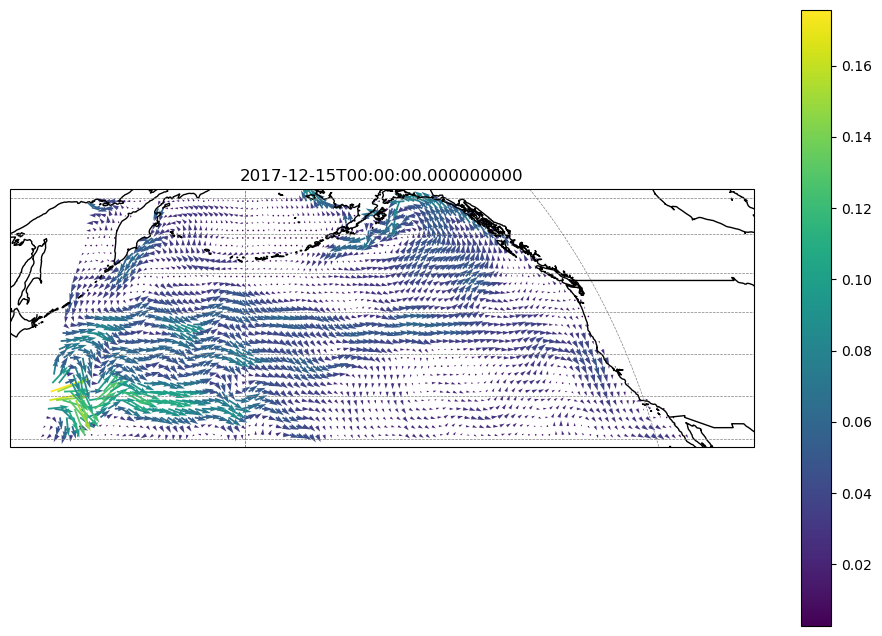

In [6]:
projection = ccrs.Mollweide(central_longitude=180)

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': projection})

U_plot = u_sel['uo'][0,:,:].values
V_plot = v_sel['vo'][0,:,:].values

c = np.sqrt(U_plot**2 + V_plot**2)  # The magnitude used in the colormap
quiver = ax.quiver(lon, lat, U_plot, V_plot, c, transform=ccrs.PlateCarree())

cbar = fig.colorbar(quiver, ax=ax)

def update(frame): 
    ax.clear()

    U_plot = u_sel['uo'][frame,:,:].values
    V_plot = v_sel['vo'][frame,:,:].values

    c = np.sqrt(U_plot**2 + V_plot**2)  # The magnitude used in the colormap
    ax.quiver(lon, lat, U_plot, V_plot, c, transform=ccrs.PlateCarree())

    ax.set_title(years[frame])
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)

ani = animation.FuncAnimation(fig, update, frames=years.shape[0], interval=1)
#ani.save('quiver_true.gif')
plt.show()

In [8]:
u[np.isnan(u)] = 0
v[np.isnan(v)] = 0
ssh[np.isnan(ssh)] = 0

t_grid, y_grid, x_grid = np.meshgrid(u_sel.time.values, lat, lon, indexing='ij') # Indexing required to get right shape

x_train = torch.tensor(x_grid, dtype=torch.float32, requires_grad=True)
y_train = torch.tensor(y_grid, dtype=torch.float32, requires_grad=True)
t_train = torch.tensor(t_grid, dtype=torch.float32, requires_grad=True)
u_train = torch.tensor(u, dtype=torch.float32)
v_train = torch.tensor(v, dtype=torch.float32)
ssh_train = torch.tensor(ssh, dtype=torch.float32)

(720, 30, 100)


In [10]:
predict = torch.stack((x_train, y_train, t_train), axis=0)
print(predict.shape)

torch.Size([3, 720, 30, 100])


In [22]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.conv1 = nn.Conv3d(3, 16, kernel_size=(3, 3, 3), stride=1, padding=1)
        self.conv2 = nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=1, padding=1)
        self.conv3 = nn.Conv3d(32, 2, kernel_size=(3, 3, 3), stride=1, padding=1)
    
    def forward(self, x):
        x = self.conv1(x)
        x = nn.functional.relu(x)
        x = self.conv2(x)
        x = nn.functional.relu(x)
        x = self.conv3(x)
        return x

In [23]:
def loss_phys(f_x, f_y, c):
    return torch.mean((f_x - 0)**2 + (f_y - 0)**2 + (c - 0)**2)

In [24]:
def loss_data(u, v, ssh): 
    return torch.mean((u - u_train)**2 + (v - v_train)**2 + (ssh - ssh_train)**2)
    # return torch.mean((u - u_train)**2 + (v - v_train)**2 + (ssh - p_train)**2)

In [25]:
def function(x, y, t):
    predict = model(torch.stack((x, y, t), axis=0))
    psi = predict[0, :, :, :]
    ssh = predict[1, :, :, :]

    u = torch.autograd.grad(psi, y, grad_outputs=torch.ones_like(psi), create_graph=True)[0]
    v = -1 * torch.autograd.grad(psi, x, grad_outputs=torch.ones_like(psi), create_graph=True)[0]

    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]

    v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]

    ssh_x = torch.autograd.grad(ssh, x, grad_outputs=torch.ones_like(ssh), create_graph=True)[0]
    ssh_y = torch.autograd.grad(ssh, y, grad_outputs=torch.ones_like(ssh), create_graph=True)[0]

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    v_t = torch.autograd.grad(v, t, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    
    # u = torch.tensor(scaler_u.inverse_transform(u.detach().numpy()), dtype=torch.float32)
    # v = torch.tensor(scaler_v.inverse_transform(v.detach().numpy()), dtype=torch.float32)
    # ssh = torch.tensor(scaler_ssh.inverse_transform(ssh.detach().numpy()), dtype=torch.float32)

    # scale_x = scaler_x.scale_[0] 
    # scale_y = scaler_y.scale_[0]
    # scale_t = scaler_t.scale_[0]
    
    # u_x = u_x / scale_x
    # u_xx = u_xx / (scale_x**2)
    # u_y = u_y / scale_y
    # u_yy = u_yy / (scale_y**2)

    # v_x = v_x / scale_x
    # v_xx = v_xx / (scale_x**2)
    # v_y = v_y / scale_y
    # v_yy = v_yy / (scale_y**2)

    # ssh_x = ssh_x / scale_x
    # ssh_y = ssh_y / scale_y

    # u_t = u_t / scale_t
    # v_t = v_t / scale_t

    c = u_x + v_y
    
    f_x = u_t + u * u_x + v * u_y + g * ssh_x - nu * (u_xx + u_yy)
    f_y = v_t + u * v_x + v * v_y + g * ssh_y - nu * (v_xx + v_yy)

    return u, v, ssh, f_x, f_y, c

In [26]:
def closure():
    optimizer.zero_grad()
    u_pred, v_pred, ssh_pred, f_x, f_y, c = function(x_train, y_train, t_train)
    loss = loss_data(u_pred, v_pred, ssh_pred) + loss_phys(f_x, f_y, c) 
    loss.backward()
    return loss

In [27]:
# Training function
def train(model, optimizer, num_epochs = 10000):
    prev_loss = float('inf')  
    for epoch in range(1, num_epochs + 1):
        loss = optimizer.step(closure) # This is for LBFGS
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item()}')
        if loss.item() >= prev_loss:
            break # Stop iteration if loss isn't decreasing
        prev_loss = loss.item()

In [28]:
# Initialize model and optimizer
model = PINN()

# LBFGS optimizer best for handling second derivative information and small datasets
# requires a closure() to perform the loss function multiple times, and be consistent
optimizer = optim.LBFGS(model.parameters(), lr = 1)
# optimizer = optim.Adam(model.parameters(), lr = 0.001)

# Train the model
train(model, optimizer)

Epoch [1/10000], Loss: 18.21278190612793
Epoch [2/10000], Loss: 0.2516670525074005
Epoch [3/10000], Loss: 0.11207804828882217
Epoch [4/10000], Loss: 0.07232001423835754
Epoch [5/10000], Loss: 0.056801531463861465
Epoch [6/10000], Loss: 0.0455479696393013
Epoch [7/10000], Loss: 0.0410497672855854
Epoch [8/10000], Loss: 0.03957521170377731
Epoch [9/10000], Loss: 0.0379280149936676
Epoch [10/10000], Loss: 0.03728358447551727
Epoch [11/10000], Loss: 0.036473456770181656
Epoch [12/10000], Loss: 0.03558458015322685
Epoch [13/10000], Loss: 0.03490879759192467
Epoch [14/10000], Loss: 0.0345110185444355
Epoch [15/10000], Loss: 0.034083038568496704
Epoch [16/10000], Loss: 0.0337366946041584
Epoch [17/10000], Loss: 0.03327341377735138
Epoch [18/10000], Loss: 0.03513915464282036


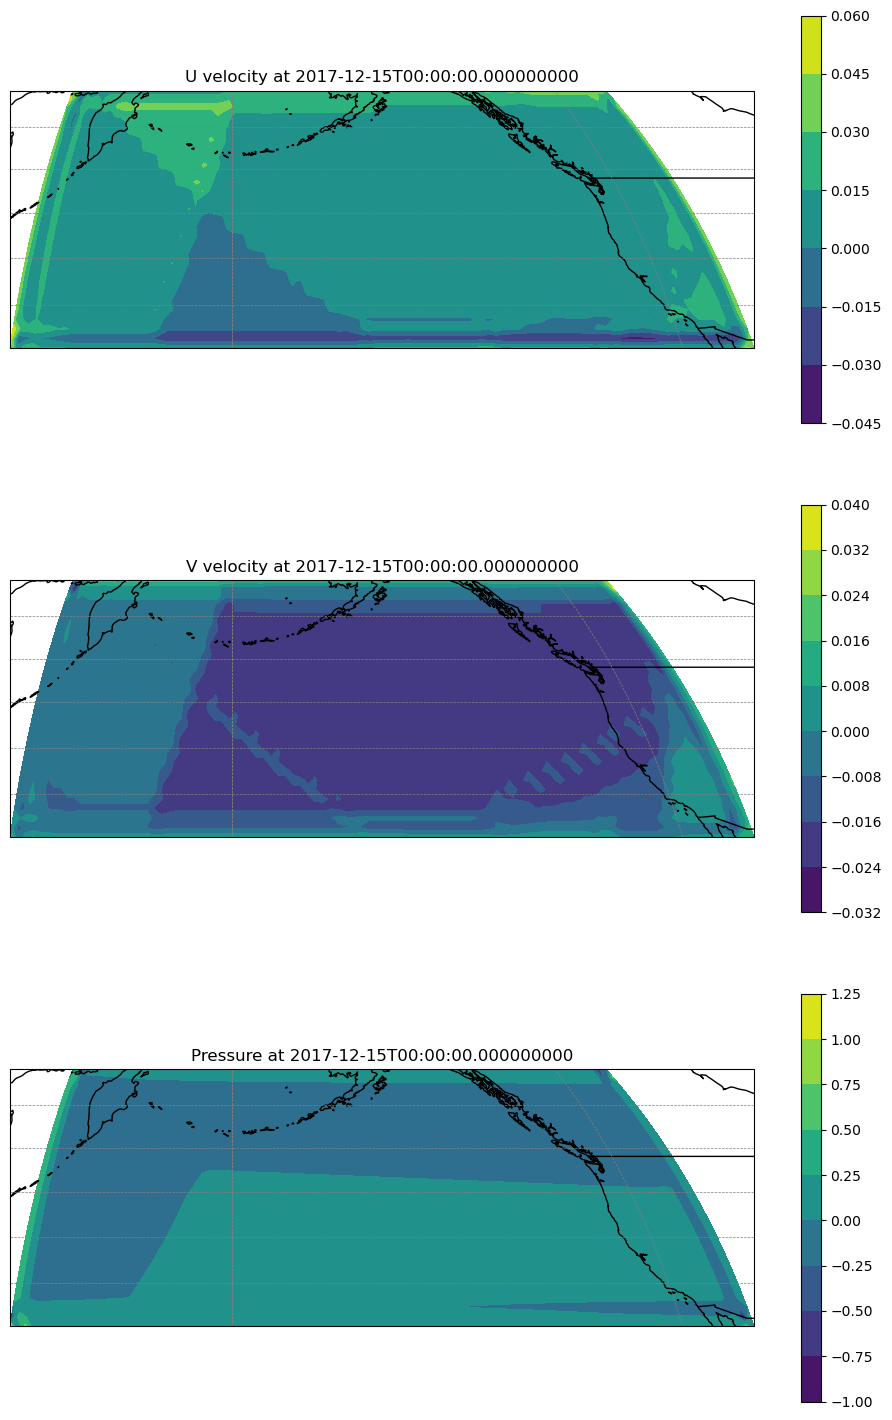

In [35]:
projection = ccrs.Mollweide(central_longitude=180)

fig, ax = plt.subplots(3, 1, figsize=(12, 18), subplot_kw={'projection': projection})

u_pred, v_pred, ssh_pred, _ , _ , _ = function(x_train, y_train, t_train)
u_numpy = u_pred.detach().numpy()
v_numpy = v_pred.detach().numpy()
ssh_numpy = ssh_pred.detach().numpy()
U_plot = u_numpy[0,:,:]
V_plot = v_numpy[0,:,:]
SSH_plot = ssh_numpy[0,:,:]

pcf0 = ax[0].contourf(lon, lat, U_plot, transform=ccrs.PlateCarree(), cmap='viridis') # Same as plotting xarray
pcf1 = ax[1].contourf(lon, lat, V_plot, transform=ccrs.PlateCarree(), cmap='viridis')
pcf2 = ax[2].contourf(lon, lat, SSH_plot, transform=ccrs.PlateCarree(), cmap='viridis')

cbar0 = fig.colorbar(pcf0, ax=ax[0])
cbar1 = fig.colorbar(pcf1, ax=ax[1])
cbar2 = fig.colorbar(pcf2, ax=ax[2])

def update(frame): 
    ax[0].clear()
    ax[1].clear()
    ax[2].clear()
    
    U_plot = u_numpy[frame,:,:]
    V_plot = v_numpy[frame,:,:]
    SSH_plot = ssh_numpy[frame,:,:]

    ax[0].contourf(lon, lat, U_plot, transform=ccrs.PlateCarree(), cmap='viridis') # Same as plotting xarray
    ax[1].contourf(lon, lat, V_plot, transform=ccrs.PlateCarree(), cmap='viridis')
    ax[2].contourf(lon, lat, SSH_plot, transform=ccrs.PlateCarree(), cmap='viridis')

    ax[0].set_title(f'U velocity at {years[frame]}')
    ax[1].set_title(f'V velocity at {years[frame]}')
    ax[2].set_title(f'Pressure at {years[frame]}')
    
    ax[0].coastlines()
    ax[0].add_feature(cfeature.BORDERS)
    ax[0].gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)
    
    ax[1].coastlines()
    ax[1].add_feature(cfeature.BORDERS)
    ax[1].gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)
    
    ax[2].coastlines()
    ax[2].add_feature(cfeature.BORDERS)
    ax[2].gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)

ani = animation.FuncAnimation(fig, update, frames=years.shape[0], interval=1)
ani.save('contour_pred.gif')
plt.show()

C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\quiver.py:645: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\quiver.py:645: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))
C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\quiver.py:645: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\quiver.py:645: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))
C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\quiver.py:645: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
C:\Users\angel\anaconda3\Lib\site-packages\matplotlib\quiver.p

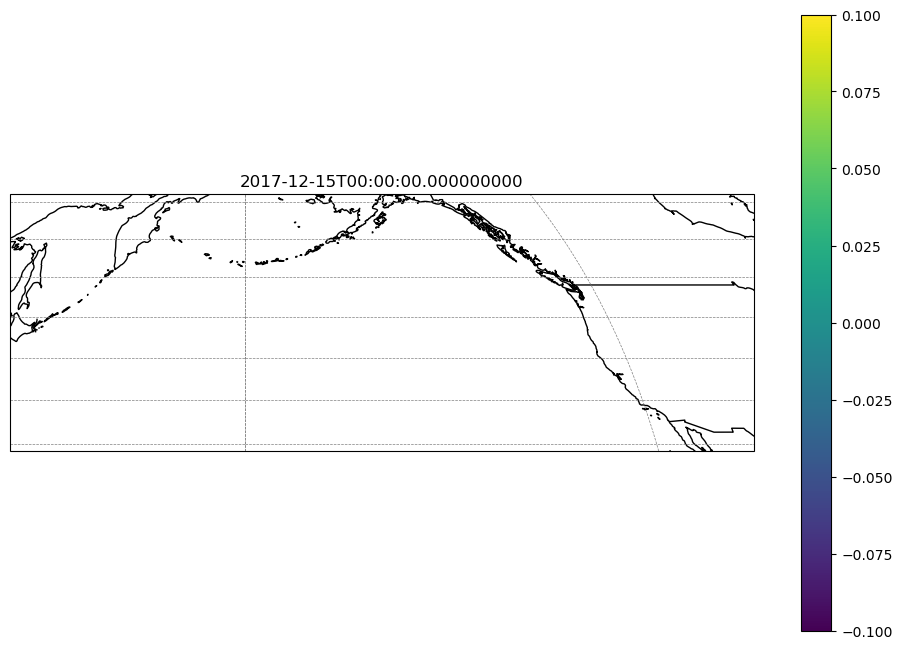

In [27]:
projection = ccrs.Mollweide(central_longitude=180)

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': projection})

t_test = torch.full(x_test.shape, u_sel['time'].values[0], dtype=torch.float32, requires_grad=True)
u_pred, v_pred, ssh_pred, _ , _ , _ = function(x_test, y_test, t_test * u_sel['time'].values[0])
mask = u[0,:,:].flatten()
indx = np.where(~np.isnan(mask))

U_mask = mask.copy()
U_mask[indx] = u_pred.detach().numpy().flatten()
U_plot = U_mask.reshape(lat.shape[0], lon.shape[0]) 

V_mask = mask.copy()
V_mask[indx] = v_pred.detach().numpy().flatten()
V_plot = V_mask.reshape(lat.shape[0], lon.shape[0]) 

c = np.sqrt(U_plot**2 + V_plot**2)  # The magnitude used in the colormap
quiver = ax.quiver(lon, lat, U_plot, V_plot, c, transform=ccrs.PlateCarree())

cbar = fig.colorbar(quiver, ax=ax)

def update(frame): 
    ax.clear()

    t_test = torch.full(x_test.shape, u_sel['time'].values[frame], dtype=torch.float32, requires_grad=True)
    u_pred, v_pred, ssh_pred, _ , _ , _ = function(x_test, y_test, t_test * u_sel['time'].values[frame])

    U_mask[indx] = u_pred.detach().numpy().flatten()
    U_plot = U_mask.reshape(lat.shape[0], lon.shape[0]) 

    V_mask[indx] = v_pred.detach().numpy().flatten()
    V_plot = V_mask.reshape(lat.shape[0], lon.shape[0]) 

    c = np.sqrt(U_plot**2 + V_plot**2)  # The magnitude used in the colormap
    ax.quiver(lon, lat, U_plot, V_plot, c, transform=ccrs.PlateCarree())

    ax.set_title(years[frame])
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)

ani = animation.FuncAnimation(fig, update, frames=years.shape[0], interval=1)
ani.save('quiver_pred.gif')
plt.show()